## Cross-Subject Sleep Stage Classification from EEG Signals
---

### Project Information
- **Course:** Cross-Subject Sleep Stage Classification from EEG Signals
- **Group number:** ML_SE_ALL_09
- **Team members:**
  - Abhi Sanjaybhai Golakiya   54704899
  - Rishab Hanamar             48537179
  - Miten Mistry               64406860
  - Avi Rajeshkumar Mistry     44429419
---

### Problem Statement
- Sleep-stage models may perform well when training and testing contain data from the same people.
- Their performance can decrease when they are tested on completely unseen people.
- This project studies **cross-subject generalisation**.
- The task is five-class multiclass classification:
  - Wake
  - N1
  - N2
  - N3
  - REM
- A classical feature-based **Random Forest** is compared with a **Compact 1D CNN**
---


### Main project question

**Can models trained using EEG recordings from some people correctly classify the sleep stages of completely unseen people?**

---

### Dataset: Sleep-EDF Database Expanded
- **Input:** 2 EEG channels from one 30-second period.
- **Output:** Wake, N1, N2, N3 or REM.
---



# Stage 0 - Prepare the notebook

This stage imports the required libraries.

### Library purposes

| Library | Purpose |
|---|---|
| NumPy and pandas | Arrays and tables |
| Matplotlib | Project figures |
| MNE | Reading and filtering EDF EEG recordings |
| SciPy | Frequency features |
| scikit-learn | Random Forest and evaluation |
| TensorFlow/Keras | Compact 1D CNN |
| Joblib | Saving the Random Forest model |



In [2]:
# These libraries are used for:
# - reading and processing EEG files,
# - creating tables and graphs,
# - training the two models,
# - checking the model results.

# Run this only if packages are missing.
# %pip install numpy pandas scipy matplotlib mne scikit-learn joblib tensorflow


# Basic Python libraries
from pathlib import Path
import gc
import json
import random
import time
import warnings


# Data and graph libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# EEG processing library
import mne


# Display tables in the notebook
from IPython.display import display


# EEG frequency feature calculation
from scipy.signal import welch
from scipy.integrate import trapezoid


# Random Forest model and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# Used to handle unequal sleep-stage classes
from sklearn.utils.class_weight import compute_class_weight


# Used to save and load the Random Forest model
import joblib


# TensorFlow is used for the Compact 1D CNN
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense


# Stops CNN training when validation results stop improving
from tensorflow.keras.callbacks import EarlyStopping


# Keep the random results repeatable
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("Libraries imported successfully.")

c:\Users\risha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries imported successfully.


c:\Users\risha\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Stage 1 - Set paths and project values
- supports the supplied Windows path
- checks common local folders
- checks Google Drive when running in Colab
- saves every generated file inside one project-output folder
- reuses completed processing and trained models


In [3]:
# Path of the Sleep-EDF dataset on this laptop
MY_DATA_FOLDER = Path(
    r"C:\Users\risha\RISHAB\University\Semester_2\Machine_Learning\Final_Project\sleep-edf-database-expanded-1.0.0\sleep-edf-database-expanded-1.0.0\sleep-cassette"
)


# Start by assuming that the notebook is not running in Google Colab
RUNNING_IN_COLAB = False

try:
    # This import works only when the notebook runs in Google Colab
    from google.colab import drive

    # Connect Google Drive to the Colab notebook
    drive.mount("/content/drive")

    # Remember that the notebook is running in Colab
    RUNNING_IN_COLAB = True

except ImportError:
    # Do nothing when the notebook runs locally
    pass


# Different possible locations where the dataset may be stored
possible_data_folders = [
    MY_DATA_FOLDER,
    Path("/content/drive/MyDrive/SleepEDF/sleep-cassette"),
    Path.cwd() / "sleep-cassette",
    Path.cwd() / "SleepEDF" / "sleep-cassette",
]


# Select the first dataset folder that exists
RAW_DATA_DIR = next(
    (
        folder
        for folder in possible_data_folders
        if folder.exists()
    ),
    None,
)


# Stop the notebook when the dataset folder cannot be found
if RAW_DATA_DIR is None:
    raise FileNotFoundError(
        "The sleep-cassette folder was not found. "
        "Change MY_DATA_FOLDER at the top of this cell."
    )


# Select the main folder where project outputs will be stored
if RUNNING_IN_COLAB:
    # Save outputs in Google Drive when using Colab
    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/Sleep_Stage_Project"
    )
else:
    # Save outputs beside the notebook when running locally
    PROJECT_ROOT = (
        Path.cwd()
        / "Sleep_Stage_Project"
    )


# Folder for processed EEG data
PROCESSED_DIR = PROJECT_ROOT / "processed"

# Folder for CSV result files
RESULTS_DIR = PROJECT_ROOT / "results"

# Folder for generated graphs and figures
FIGURES_DIR = PROJECT_ROOT / "figures"

# Folder for trained machine-learning models
MODELS_DIR = PROJECT_ROOT / "models"


# Create all output folders when they do not already exist
for folder in [
    PROCESSED_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    MODELS_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


# The two EEG channels given to the models
EEG_CHANNELS = [
    "EEG Fpz-Cz",
    "EEG Pz-Oz",
]


# The five sleep stages predicted by the models
CLASS_NAMES = [
    "Wake",
    "N1",
    "N2",
    "N3",
    "REM",
]


# Convert each sleep-stage name into a number
LABEL_TO_ID = {
    "Wake": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "REM": 4,
}


# Convert each number back into its sleep-stage name
ID_TO_LABEL = {
    number: name
    for name, number
    in LABEL_TO_ID.items()
}


# Length of one EEG sample
# One sample contains 30 seconds of EEG data
EPOCH_SECONDS = 30


# Remove signal changes slower than 0.5 Hz
# This helps remove very slow signal drift
LOW_CUT_HZ = 0.5


# Remove frequencies higher than 40 Hz
# This helps reduce high-frequency noise
HIGH_CUT_HZ = 40.0


# Keep 30 minutes of Wake before sleep starts
# and 30 minutes after sleep finishes
WAKE_MARGIN_MINUTES = 30


# None means there is no maximum sample limit
# Every usable sample from each recording is considered
SAMPLES_PER_RECORDING = None


# Number used to identify the processed-data format
# Change this only when the processed-file structure changes
CACHE_VERSION = 4


# False means existing processed data can be reused
# True means the raw EEG recordings are processed again
FORCE_PROCESS_DATA = False


# False means existing trained models can be reused
# True means the models are trained again
FORCE_TRAIN_MODELS = False


# Create a name for this experiment
# The name includes the cache version, sample setting and random seed
RUN_TAG = f"v{CACHE_VERSION}_n{SAMPLES_PER_RECORDING}_seed{SEED}"


# Display the important settings before processing starts
print("Dataset folder:", RAW_DATA_DIR)
print("Output folder:", PROJECT_ROOT)
print("Selected EEG channels:", EEG_CHANNELS)


Dataset folder: C:\Users\risha\RISHAB\University\Semester_2\Machine_Learning\Final_Project\sleep-edf-database-expanded-1.0.0\sleep-edf-database-expanded-1.0.0\sleep-cassette
Output folder: c:\Users\risha\RISHAB\University\Semester_2\Machine_Learning\Final_Project\Sleep_Stage_Project
Selected EEG channels: ['EEG Fpz-Cz', 'EEG Pz-Oz']


# Stage 2 - Match PSG and Hypnogram files

Each night data has two required files:

- **PSG:** the continuous recorded signals.
- **Hypnogram:** the sleep-stage labels written by experts.
---

In this stage, the following is carried out
- finds all PSG files,
- finds all Hypnogram files,
- matches the correct PSG and Hypnogram files,
- creates training, validation and test subject groups,
- checks that the same subject is not used in multiple groups,
- saves information about the split,
- creates a graph of the subject split.


PSG files found: 153
Hypnogram files found: 153
Matched recordings: 153
Unique subjects: 78
Training subjects: 54
Validation subjects: 11
Test subjects: 13
Subject leakage check passed.


,subject_id,recording_id,psg_file,hypnogram_file
0,SC400,SC4001,C:\Users\risha\RISHAB\University\Semester_2\Ma...,C:\Users\risha\RISHAB\University\Semester_2\Ma...
1,SC400,SC4002,C:\Users\risha\RISHAB\University\Semester_2\Ma...,C:\Users\risha\RISHAB\University\Semester_2\Ma...
2,SC401,SC4011,C:\Users\risha\RISHAB\University\Semester_2\Ma...,C:\Users\risha\RISHAB\University\Semester_2\Ma...
3,SC401,SC4012,C:\Users\risha\RISHAB\University\Semester_2\Ma...,C:\Users\risha\RISHAB\University\Semester_2\Ma...
4,SC402,SC4021,C:\Users\risha\RISHAB\University\Semester_2\Ma...,C:\Users\risha\RISHAB\University\Semester_2\Ma...


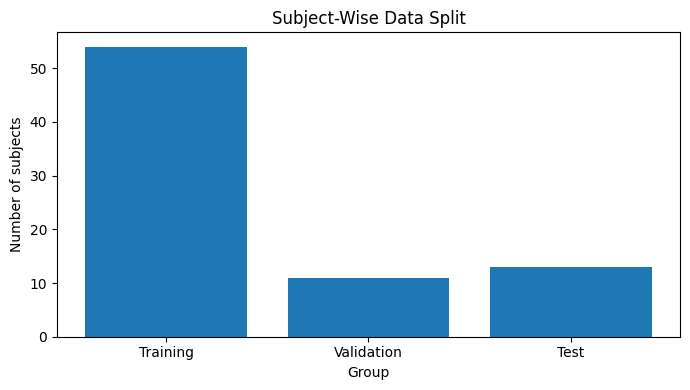

In [4]:
# Find all PSG files inside the dataset folder
# PSG files contain the recorded EEG signals
psg_files = sorted(
    RAW_DATA_DIR.glob("*-PSG.edf")
)


# Find all Hypnogram files inside the dataset folder
# Hypnogram files contain the sleep-stage labels
hypnogram_files = sorted(
    RAW_DATA_DIR.glob("*-Hypnogram.edf")
)


# The first six characters of the filename identify one recording
# Example:
# SC4001E0-PSG.edf        → SC4001
# SC4001EC-Hypnogram.edf  → SC4001
#
# This dictionary connects each recording key
# to its matching Hypnogram file
#
#{
#    'SC4001': WindowsPath('C:/Users/risha/Downloads/sleep-cassette/SC4001EC-Hypnogram.edf'),
#    'SC4002': WindowsPath('C:/Users/risha/Downloads/sleep-cassette/SC4002EC-Hypnogram.edf'),
#    'SC4011': WindowsPath('C:/Users/risha/Downloads/sleep-cassette/SC4011EH-Hypnogram.edf')
#}

hypnogram_by_key = {
    file.name[:6]: file
    for file in hypnogram_files
}


# This list will store information about every matched recording
recording_rows = []


# Go through every PSG file
for psg_file in psg_files:

    # Get the recording key from the PSG filename
    recording_key = psg_file.name[:6]


    # Search for the Hypnogram file with the same recording key
    hypnogram_file = hypnogram_by_key.get(
        recording_key
    )


    # Continue only when a matching Hypnogram file was found
    if hypnogram_file is not None:

        # Save the subject, recording and file information
        recording_rows.append({
            "subject_id": psg_file.name[:5],
            "recording_id": recording_key,
            "psg_file": str(psg_file),
            "hypnogram_file": str(hypnogram_file),
        })
# Example
#{
#    "subject_id": "SC400",
#    "recording_id": "SC4001",
#    "psg_file": "C:\\...\\SC4001E0-PSG.edf",
#    "hypnogram_file": "C:\\...\\SC4001EC-Hypnogram.edf",
#}
    


# Convert the matched recording information into a table
recordings_df = pd.DataFrame(
    recording_rows
)


# Stop the notebook when no matching file pairs were found
if recordings_df.empty:
    raise ValueError(
        "No matching PSG and Hypnogram files were found."
    )


# Create a subject-wise 70/15/15 split
#
# 70% of subjects are used for training
# 15% of subjects are used for validation
# 15% of subjects are used for final testing


# Get every unique subject only once
subjects = sorted(
    recordings_df["subject_id"].unique()
)


# Create a repeatable random-number generator
# SEED makes the same subject split appear every time
random_generator = np.random.default_rng(
    SEED
)


# Randomly change the order of the subjects
random_generator.shuffle(
    subjects
)


# Count the total number of unique subjects
number_of_subjects = len(subjects)


# Find where the training group ends
# The first 70% of subjects will be used for training
train_end = int(
    number_of_subjects * 0.70
)


# Find where the validation group ends
# The next 15% of subjects will be used for validation
validation_end = (
    train_end
    + int(number_of_subjects * 0.15)
)


# Select the training subjects
train_subjects = subjects[:train_end]


# Select the validation subjects
validation_subjects = subjects[
    train_end:validation_end
]


# Select the remaining subjects for testing
test_subjects = subjects[
    validation_end:
]


# Check for subject leakage
#
# Subject leakage would happen if the same person
# appeared in training, validation or testing more than once


# Check that no training subject is in validation
assert set(train_subjects).isdisjoint(
    validation_subjects
)


# Check that no training subject is in testing
assert set(train_subjects).isdisjoint(
    test_subjects
)


# Check that no validation subject is in testing
assert set(validation_subjects).isdisjoint(
    test_subjects
)


# Store the three subject groups in one dictionary
subject_split = {
    "train": list(train_subjects),
    "validation": list(validation_subjects),
    "test": list(test_subjects),
}


# Save the subject split as a JSON file
# This allows the same subject groups to be checked later
with open(
    RESULTS_DIR / "subject_split.json",
    "w",
) as file:
    json.dump(
        subject_split,
        file,
        indent=2,
    )


# Save the matched PSG and Hypnogram file table as a CSV file
recordings_df.to_csv(
    RESULTS_DIR / "recording_pairs.csv",
    index=False,
)


# Display the number of files, recordings and subjects
print("PSG files found:", len(psg_files))

print(
    "Hypnogram files found:",
    len(hypnogram_files),
)

print(
    "Matched recordings:",
    len(recordings_df),
)

print(
    "Unique subjects:",
    number_of_subjects,
)

print(
    "Training subjects:",
    len(train_subjects),
)

print(
    "Validation subjects:",
    len(validation_subjects),
)

print(
    "Test subjects:",
    len(test_subjects),
)

print("Subject leakage check passed.")


# Show the first five matched recordings
display(
    recordings_df.head()
)


# Names shown below the bars in the graph
split_names = [
    "Training",
    "Validation",
    "Test",
]


# Number of subjects in each group
split_counts = [
    len(train_subjects),
    len(validation_subjects),
    len(test_subjects),
]


# Create a new graph
plt.figure(figsize=(7, 4))


# Create one bar for each subject group
plt.bar(
    split_names,
    split_counts,
)


# Add the graph title
plt.title(
    "Subject-Wise Data Split"
)


# Add the horizontal-axis label
plt.xlabel("Group")


# Add the vertical-axis label
plt.ylabel("Number of subjects")


# Adjust spacing so that labels are not cut off
plt.tight_layout()


# Save the graph as an image
plt.savefig(
    FIGURES_DIR / "subject_split.png",
    dpi=150,
)


# Display the graph inside the notebook
plt.show()


## Dataset Summary

- **Dataset:** Sleep-EDF Database Expanded
- **Source:** PhysioNet - https://physionet.org/content/sleep-edfx/
- **Dataset subset used:** `sleep-cassette`
- **File format:** EDF
- **Task type:** Five-class multiclass classification
- **Files used:**
  - PSG files contain the recorded physiological signals.
  - Hypnogram files contain the expert sleep-stage annotations.
- **EEG channels used:**
  - EEG Fpz-Cz
  - EEG Pz-Oz
- **Final labels:** Wake, N1, N2, N3 and REM
- **PSG files found:** 153
- **Hypnogram files found:** 153
- **Matched recordings:** 153
- **Unmatched recordings:** 0
- **Unique subjects:** 78
- **Subject split:**
  - Training: 54 subjects
  - Validation: 11 subjects
  - Test: 13 subjects
- **Sampling rate:** 100 Hz
- **Usable 30-second samples after preprocessing:** 195,479
- **Samples used for modelling:** 195,479
- **Sampling method:** All usable 30-second samples are considered.
- **Processed EEG dataset files saved:** No
- **Class check:** All five sleep-stage classes are present in the modelling data.
---

## Subject Split Significance:
- Each person produces many 30-second EEG samples.
- All samples from one person are kept in only one group: training, validation, or testing.
- This prevents the model from seeing the same person during both training and testing.
- Therefore, the final test checks whether the model can correctly classify sleep stages for completely new people.
---

# Stage 3 - Two selected EEG channels

The PSG files contain several types of physiological signals. This project focuses specifically on EEG.

### Selected channels

| Channel | Approximate head region | Project reason |
|---|---|---|
| EEG Fpz-Cz | Frontal to central | Provides front/central EEG information |
| EEG Pz-Oz | Parietal to occipital | Provides back-of-head EEG information |

Both are used because they are the two EEG channels supplied in the `sleep-cassette` recordings.

Signals such as EOG and EMG are not used because that would change the project from **EEG-only classification** to multimodal classification.


,Channel in PSG file,Used in project,Reason
0,EEG Fpz-Cz,Yes,Selected EEG channel
1,EEG Pz-Oz,Yes,Selected EEG channel
2,EOG horizontal,No,Not one of the two selected EEG channels
3,Resp oro-nasal,No,Not one of the two selected EEG channels
4,EMG submental,No,Not one of the two selected EEG channels
5,Temp rectal,No,Not one of the two selected EEG channels
6,Event marker,No,Not one of the two selected EEG channels


Reading 0 ... 2999  =      0.000 ...    29.990 secs...


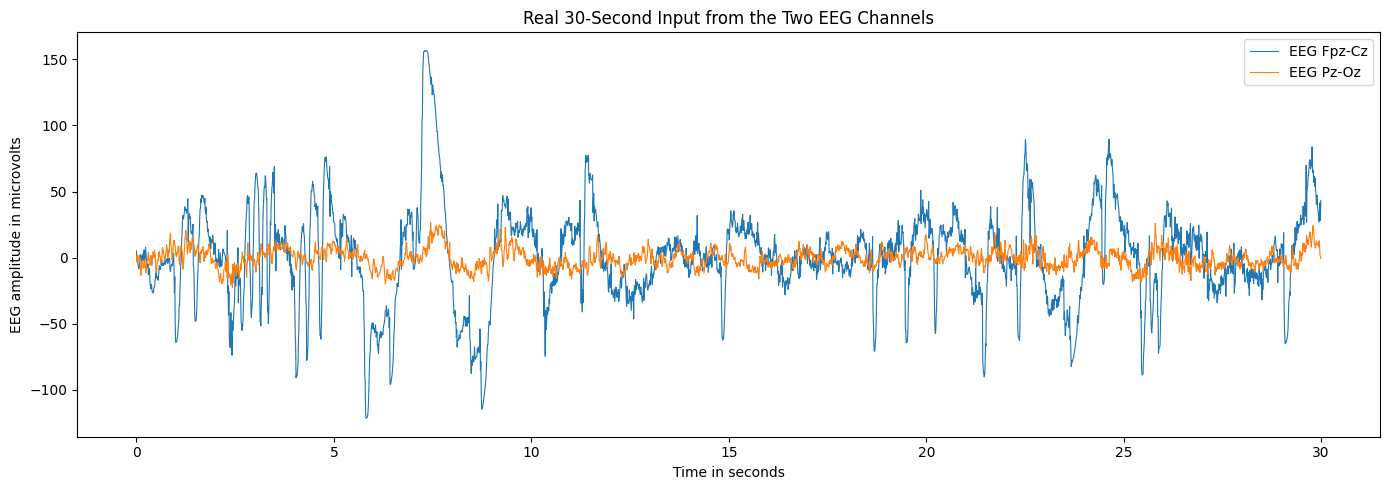

In [5]:
# Get the first PSG file from the recordings table.
first_psg_file = recordings_df.iloc[0][
    "psg_file"
]


# Open the PSG file without showing unnecessary warnings.
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=RuntimeWarning,
    )

    first_raw = mne.io.read_raw_edf(
        first_psg_file,
        preload=False,
        verbose="ERROR",
    )


# Create a list for information about every channel.
channel_rows = []


# Check every channel available in the PSG file.
for channel_name in first_raw.ch_names:

    # Check whether this channel is used in the project.
    is_selected = (
        channel_name in EEG_CHANNELS
    )

    # Store the channel name and selection information.
    channel_rows.append({
        "Channel in PSG file": channel_name,
        "Used in project": (
            "Yes"
            if is_selected
            else "No"
        ),
        "Reason": (
            "Selected EEG channel"
            if is_selected
            else "Not one of the two selected EEG channels"
        ),
    })


# Convert the channel information into a table.
channel_table = pd.DataFrame(
    channel_rows
)


# Display the channel table.
display(channel_table)


# Read only the two selected EEG channels.
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=RuntimeWarning,
    )

    channel_example = mne.io.read_raw_edf(
        first_psg_file,
        include=EEG_CHANNELS,
        preload=False,
        verbose="ERROR",
    )


# Keep only the first 30 seconds.
channel_example.crop(
    tmin=0,
    tmax=EPOCH_SECONDS,
    include_tmax=False,
)


# Load the selected EEG data into memory.
channel_example.load_data()


# Get the EEG values and convert volts to microvolts.
example_data = (
    channel_example.get_data()
    * 1e6
)


# Get the number of EEG values recorded per second.
example_sampling_rate = int(
    channel_example.info["sfreq"]
)


# Create the time values for the horizontal axis.
time_axis = (
    np.arange(example_data.shape[1])
    / example_sampling_rate
)


# Create a figure for the two EEG channels.
plt.figure(figsize=(14, 5))


# Plot each selected EEG channel.
for channel_number, channel_name in enumerate(
    EEG_CHANNELS
):
    plt.plot(
        time_axis,
        example_data[channel_number],
        linewidth=0.8,
        label=channel_name,
    )


# Add the graph title and axis labels.
plt.title(
    "Real 30-Second Input from the Two EEG Channels"
)
plt.xlabel("Time in seconds")
plt.ylabel("EEG amplitude in microvolts")
plt.legend()
plt.tight_layout()


# Save the graph as an image.
plt.savefig(
    FIGURES_DIR / "two_selected_eeg_channels.png",
    dpi=150,
)


# Display the graph.
plt.show()


# Close both opened EEG files.
first_raw.close()
channel_example.close()


# Stage 4 - Convertion of each night into labelled 30-second samples

## 30 second epoch:

The Hypnogram provides sleep-stage labels in 30-second intervals.

Therefore:

One 30-second EEG segment = one machine-learning sample = one sleep-stage label

At a sampling rate of 100 Hz, one EEG channel contains **3,000 measurements in 30 seconds**.

With two EEG channels, one input sample has the shape:

`(3000, 2)`

This means:

- 3,000 time points
- 2 EEG channels
---

## Label conversion

| Original Sleep-EDF label | Final project label |
|---|---|
| Sleep stage W | Wake |
| Sleep stage 1 | N1 |
| Sleep stage 2 | N2 |
| Sleep stage 3 | N3 |
| Sleep stage 4 | N3 |
| Sleep stage R | REM |
| Movement / unknown | Excluded |

---

## 0.5 and 40 Hz filter:

- Frequencies below 0.5 Hz can contain very slow signal drift.
- Frequencies above 40 Hz are not required for this project.
- The selected range keeps the main EEG frequency information used for sleep-stage classification.
---

## 30 minutes of Wake around sleep:

Full-night recordings may contain long Wake periods before and after sleep. Keeping all of them could cause the Wake class to **dominate the dataset**.

---


In [6]:
# SHOW THE LABEL AND PREPROCESSING DECISIONS

label_mapping_table = pd.DataFrame({
    "Original label": [
        "Sleep stage W",
        "Sleep stage 1",
        "Sleep stage 2",
        "Sleep stage 3",
        "Sleep stage 4",
        "Sleep stage R",
        "Movement / unknown",
    ],
    "Final project decision": [
        "Wake",
        "N1",
        "N2",
        "N3",
        "N3",
        "REM",
        "Excluded",
    ],
})

display(label_mapping_table)

,Original label,Final project decision
0,Sleep stage W,Wake
1,Sleep stage 1,N1
2,Sleep stage 2,N2
3,Sleep stage 3,N3
4,Sleep stage 4,N3
5,Sleep stage R,REM
6,Movement / unknown,Excluded


In [7]:
# FUNCTIONS FOR PROCESSING ONE RECORDING

SLEEP_EDF_LABEL_MAP = {
    "Sleep stage W": "Wake",
    "Sleep stage 1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage 3": "N3",
    "Sleep stage 4": "N3",
    "Sleep stage R": "REM",
}

# In this function, the sleep start and end time is recoreded
# Also the 30 min before the Wakeup is removed and added at the end 
def find_useful_time_range(annotations):
    # Find where real sleep starts and ends.
    sleep_starts = []
    sleep_ends = []

    for onset, duration, description in zip(
        annotations.onset,
        annotations.duration,
        annotations.description,
    ):
        if (description in SLEEP_EDF_LABEL_MAP and SLEEP_EDF_LABEL_MAP[description] != "Wake"):
            sleep_starts.append(
                float(onset)
            )

            sleep_ends.append(
                float(onset + duration)
            )

    if not sleep_starts:
        return None, None

    margin_seconds = (WAKE_MARGIN_MINUTES * 60)

    #not to allow the start time to go below 0 
    start_time = max(0.0,min(sleep_starts) - margin_seconds,)

    end_time = (max(sleep_ends) + margin_seconds)

    return start_time, end_time

# 30 seconds chunks which are to be used as samples are created
# X_list contains the sample 
# Y_list contains the label
def create_30_second_samples(
    raw,
    annotations,
):
    # The cropped raw signal begins at this time
    # in the original full-night recording.
    crop_start_time = float(
        raw.first_time
    )

    eeg = raw.get_data()

    sampling_rate = int(
        raw.info["sfreq"]
    )

    values_per_sample = (
        sampling_rate
        * EPOCH_SECONDS
    )

    X_list = []
    y_list = []

    for onset, duration, description in zip(
        annotations.onset,
        annotations.duration,
        annotations.description,
    ):
        if description not in SLEEP_EDF_LABEL_MAP:
            continue

        final_label = (SLEEP_EDF_LABEL_MAP[description])

        number_of_chunks = int(
            np.floor(
                (
                    float(duration)
                    + 1e-6
                )
                / EPOCH_SECONDS
            )
        )

        for chunk_number in range(
            number_of_chunks
        ):
            chunk_start_time = (
                float(onset)
                + chunk_number
                * EPOCH_SECONDS
            )

            local_start_time = (
                chunk_start_time
                - crop_start_time
            )

            start = int(
                round(
                    local_start_time
                    * sampling_rate
                )
            )

            end = (
                start
                + values_per_sample
            )

            if (
                start >= 0
                and end <= eeg.shape[1]
            ):
                # Transpose:
                # channels x time
                # becomes time x channels.
                sample = (
                    eeg[:, start:end]
                    .T
                    .astype(np.float32)
                )

                X_list.append(sample)

                y_list.append(
                    LABEL_TO_ID[
                        final_label
                    ]
                )

    if not X_list:
        raise ValueError(
            "No complete 30-second samples were created."
        )

    X = np.asarray(
        X_list,
        dtype=np.float32,
    )

    y = np.asarray(
        y_list,
        dtype=np.int64,
    )

    return X, y, sampling_rate


# In this function each data set is prepared by adding and deleteing the 30 min timw window
# Later 30 seconds chunks which are to be used as samples are created
def process_one_recording(
    psg_file,
    hypnogram_file,
):
    # Read the labels first.
    # Note: annotations object 
    # Start time: 3000 seconds
    # Duration: 30 seconds
    # Description: Sleep stage 1
    
    annotations = mne.read_annotations(
        hypnogram_file
    )

    start_time, end_time = (
        find_useful_time_range(
            annotations
        )
    )

    if start_time is None:
        raise ValueError(
            f"No valid sleep stages found in {hypnogram_file}"
        )

    # Read only the two selected EEG channels.
    # preload=False avoids loading the whole night.
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=(
                "Channels contain different "
                "highpass filters.*"
            ),
            category=RuntimeWarning,
        )

        warnings.filterwarnings(
            "ignore",
            message=(
                "Channels contain different "
                "lowpass filters.*"
            ),
            category=RuntimeWarning,
        )

        warnings.filterwarnings(
            "ignore",
            message=(
                "Highpass cutoff frequency.*"
            ),
            category=RuntimeWarning,
        )

        raw = mne.io.read_raw_edf(
            psg_file,
            include=EEG_CHANNELS,
            preload=False,
            verbose="ERROR",
        )

    missing_channels = [
        channel
        for channel in EEG_CHANNELS
        if channel not in raw.ch_names
    ]

    if missing_channels:
        raw.close()

        raise ValueError(
            f"Missing channels in {psg_file}: "
            f"{missing_channels}"
        )

    # Crop before loading the signal.
    recording_end_time = float(
        raw.times[-1]
    )

    end_time = min(
        end_time,
        recording_end_time,
    )

    raw.crop(
        tmin=start_time,
        tmax=end_time,
        include_tmax=False,
    )

    raw.load_data()

    raw.filter(
        LOW_CUT_HZ,
        HIGH_CUT_HZ,
        verbose="ERROR",
    )

    X, y, sampling_rate = (
        create_30_second_samples(
            raw,
            annotations,
        )
    )

    raw.close()

    return X, y, sampling_rate


def choose_saved_samples(
    X,
    y,
    recording_number,
):
    if SAMPLES_PER_RECORDING is None:
        selected_indices = np.arange(
            len(y)
        )

        return (
            X,
            y,
            selected_indices,
        )

    # Save all samples when the recording is already small.
    if len(y) <= SAMPLES_PER_RECORDING:
        selected_indices = np.arange(len(y))

    else:
        recording_generator = np.random.default_rng(
            SEED + recording_number
        )

        selected_parts = []
        present_classes = np.unique(y)

        # First keep examples from every stage present in this recording.
        minimum_per_class = max(
            1,
            SAMPLES_PER_RECORDING // (2 * len(present_classes)),
        )

        for class_id in present_classes:
            class_indices = np.where(y == class_id)[0]
            class_count = min(minimum_per_class, len(class_indices))
            selected_parts.append(
                recording_generator.choice(
                    class_indices,
                    class_count,
                    replace=False,
                )
            )

        selected_indices = np.unique(
            np.concatenate(selected_parts)
        )

        # Fill the remaining positions randomly from samples not selected yet.
        remaining_count = SAMPLES_PER_RECORDING - len(selected_indices)

        if remaining_count > 0:
            remaining_indices = np.setdiff1d(
                np.arange(len(y)),
                selected_indices,
                assume_unique=False,
            )

            extra_indices = recording_generator.choice(
                remaining_indices,
                remaining_count,
                replace=False,
            )

            selected_indices = np.concatenate([
                selected_indices,
                extra_indices,
            ])

        selected_indices = np.sort(selected_indices)

    return (
        X[selected_indices],
        y[selected_indices],
        selected_indices,
    )


# Stage 5 - Process all recordings

This stage processes all matched PSG and Hypnogram recordings.

For every recording,

1. reads the sleep-stage annotations
2. reads only the two selected EEG channels
3. keeps the useful sleep period with 30 minutes of Wake before and after sleep
4. filters the cropped EEG between 0.5 Hz and 40 Hz
5. divides the EEG into labelled 30-second samples
6. assigns the recording to the training, validation or test split
7. counts the number of samples in each sleep stage
8. stores the processed EEG samples and labels in memory
---
It saves the recording summary to:

`processed_recordings.csv`

This CSV contains recording information and class counts. It does not contain the actual EEG signal values.


In [8]:

# Return the dataset split for one subject.
def get_split(subject_id):
    if subject_id in train_subjects:
        return "train"

    if subject_id in validation_subjects:
        return "validation"

    return "test"


# Store the processed EEG arrays in memory.
processed_data = {}


# Store summary information for every recording.
processed_rows = []


# Start the timer for processing.
start_clock = time.time()


# Get the total number of recordings.
total_recordings = len(
    recordings_df
)


# Process every PSG and hypnogram pair.
for recording_number, (_, row) in enumerate(
    recordings_df.iterrows(),
    start=1,
):

    # Read and preprocess one complete recording.
    X, y, sampling_rate = (
        process_one_recording(
            row["psg_file"],
            row["hypnogram_file"],
        )
    )


    # Select the samples used for modelling.
    (
    selected_X,
    selected_y,
    original_indices,
    ) = choose_saved_samples(
        X,
        y,
        recording_number,
    )


    # Count the samples belonging to each sleep stage.
    total_counts = np.bincount(
        y,
        minlength=len(CLASS_NAMES),
    )


    # Use the recording ID as the data key.
    data_key = row[
        "recording_id"
    ]


    # Store the processed recording in memory.
    processed_data[
        data_key
    ] = {
        "X": selected_X,
        "y": selected_y,
        "original_epoch_index": original_indices,
        "sampling_rate": sampling_rate,
    }


    # Store summary information about the recording.
    processed_rows.append({
        "subject_id": row["subject_id"],
        "recording_id": row["recording_id"],
        "split": get_split(
            row["subject_id"]
        ),
        "data_file": data_key,
        "sampling_rate": sampling_rate,
        "total_samples": len(y),
        "saved_samples": len(
            selected_y
        ),
        "Wake": int(
            total_counts[0]
        ),
        "N1": int(
            total_counts[1]
        ),
        "N2": int(
            total_counts[2]
        ),
        "N3": int(
            total_counts[3]
        ),
        "REM": int(
            total_counts[4]
        ),
    })


    # Show progress after every 10 recordings
    # and after the final recording.
    if (
        recording_number % 10 == 0
        or recording_number
        == total_recordings
    ):

        # Calculate the elapsed processing time.
        elapsed_minutes = (
            time.time()
            - start_clock
        ) / 60


        # Calculate the processing speed.
        rate = (
            recording_number
            / max(
                elapsed_minutes,
                1e-6,
            )
        )


        # Estimate the remaining processing time.
        remaining_minutes = (
            total_recordings
            - recording_number
        ) / max(
            rate,
            1e-6,
        )


        # Print the current processing progress.
        print(
            f"{recording_number}/{total_recordings} | "
            f"elapsed: {elapsed_minutes:.1f} min | "
            f"estimated remaining: "
            f"{remaining_minutes:.1f} min"
        )


        # Save the current recording summaries.
        pd.DataFrame(
            processed_rows
        ).to_csv(
            RESULTS_DIR
            / "processed_recordings.csv",
            index=False,
        )


# Convert all recording summaries into a table.
processed_df = pd.DataFrame(
    processed_rows
)


# Save the final recording summary table.
processed_df.to_csv(
    RESULTS_DIR
    / "processed_recordings.csv",
    index=False,
)


# Display the first five recording summaries.
display(
    processed_df.head()
)


# Print the total number of usable samples.
print(
    "Total original 30-second samples:",
    processed_df[
        "total_samples"
    ].sum(),
)


# Print the total number of samples used by the models.
print(
    "Total samples used for modelling:",
    processed_df[
        "saved_samples"
    ].sum(),
)


Reading 0 ... 2522999  =      0.000 ... 25229.990 secs...
Reading 0 ... 3383999  =      0.000 ... 33839.990 secs...
Reading 0 ... 3308999  =      0.000 ... 33089.990 secs...
Reading 0 ... 3557999  =      0.000 ... 35579.990 secs...
Reading 0 ... 3074999  =      0.000 ... 30749.990 secs...
Reading 0 ... 3029999  =      0.000 ... 30299.990 secs...
Reading 0 ... 2855999  =      0.000 ... 28559.990 secs...
Reading 0 ... 2732999  =      0.000 ... 27329.990 secs...
Reading 0 ... 3707999  =      0.000 ... 37079.990 secs...
Reading 0 ... 3611999  =      0.000 ... 36119.990 secs...
10/153 | elapsed: 0.1 min | estimated remaining: 1.1 min
Reading 0 ... 2015999  =      0.000 ... 20159.990 secs...
Reading 0 ... 3743999  =      0.000 ... 37439.990 secs...
Reading 0 ... 2528999  =      0.000 ... 25289.990 secs...
Reading 0 ... 3047999  =      0.000 ... 30479.990 secs...
Reading 0 ... 2927999  =      0.000 ... 29279.990 secs...
Reading 0 ... 3818999  =      0.000 ... 38189.990 secs...
Reading 0 ... 3

,subject_id,recording_id,split,data_file,sampling_rate,total_samples,saved_samples,Wake,N1,N2,N3,REM
0,SC400,SC4001,train,SC4001,100,841,841,188,58,250,220,125
1,SC400,SC4002,train,SC4002,100,1127,1127,183,59,373,297,215
2,SC401,SC4011,train,SC4011,100,1103,1103,157,109,562,105,170
3,SC401,SC4012,train,SC4012,100,1186,1186,162,92,660,96,176
4,SC402,SC4021,train,SC4021,100,1025,1025,128,94,545,95,163


Total original 30-second samples: 195462
Total samples used for modelling: 195462


# Stage 6 - Create sample table

This stage creates one table containing information about every 30-second EEG sample used for modelling.

For every sample, the table stores:

- a unique sample ID
- the subject ID
- the recording ID
- the training, validation or test split
- the recording data key
- the sample position inside the processed recording
- the original sample position
- the numeric sleep-stage label
- the sleep-stage name

The sample table is saved as a CSV file.

---

## Class-distribution checks

The notebook creates class-distribution graphs showing how many samples belong to:

- Wake;
- N1;
- N2;
- N3;
- REM.

Because `SAMPLES_PER_RECORDING` is set to `None`, all usable samples are kept for modelling. Therefore, the original and modelling distributions should contain the same number of samples.


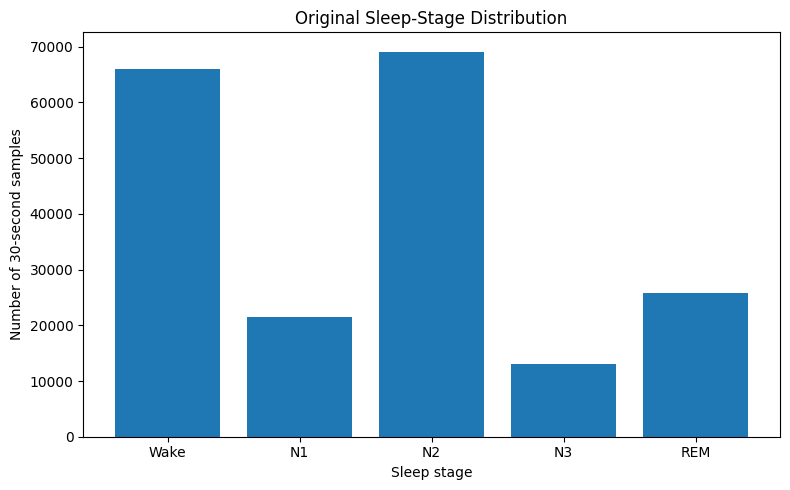

In [9]:
# CREATE THE SAMPLE TABLE AND CLASS FIGURES

sample_rows = []
sample_id = 0

for _, row in processed_df.iterrows():
    saved = processed_data[
        row["data_file"]
    ]

    y = saved["y"]

    original_indices = (
        saved[
            "original_epoch_index"
        ]
    )

    for local_index, (
        label_id,
        original_index,
    ) in enumerate(
        zip(
            y,
            original_indices,
        )
    ):
        sample_rows.append({
            "sample_id": sample_id,
            "subject_id": row[
                "subject_id"
            ],
            "recording_id": row[
                "recording_id"
            ],
            "split": row["split"],
            "data_file": row[
                "data_file"
            ],
            "local_index": local_index,
            "original_epoch_index": int(
                original_index
            ),
            "label_id": int(
                label_id
            ),
            "label_name": ID_TO_LABEL[
                int(label_id)
            ],
        })

        sample_id += 1


selected_samples_df = pd.DataFrame(
    sample_rows
)

selected_samples_df.to_csv(
    RESULTS_DIR
    / f"selected_samples_{RUN_TAG}.csv",
    index=False,
)


# Original distribution before sample selection.
original_counts = (
    processed_df[
        CLASS_NAMES
    ]
    .sum()
    .reindex(
        CLASS_NAMES
    )
)

plt.figure(figsize=(8, 5))
plt.bar(
    original_counts.index,
    original_counts.values,
)
plt.title(
    "Original Sleep-Stage Distribution"
)
plt.xlabel("Sleep stage")
plt.ylabel(
    "Number of 30-second samples"
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR
    / "original_class_distribution.png",
    dpi=150,
)
plt.show()


# Distribution after the laptop-friendly sample limit.
selected_counts = (
    selected_samples_df[
        "label_name"
    ]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0,
    )
)

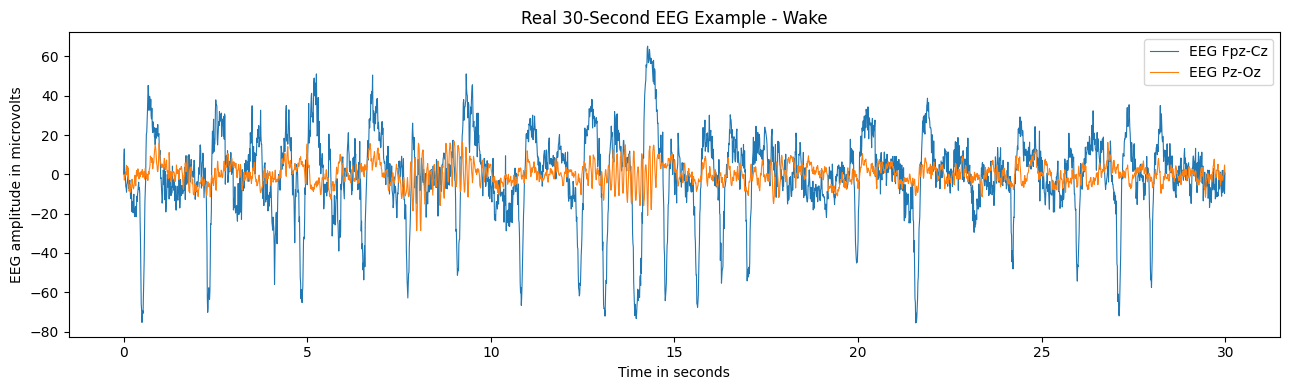

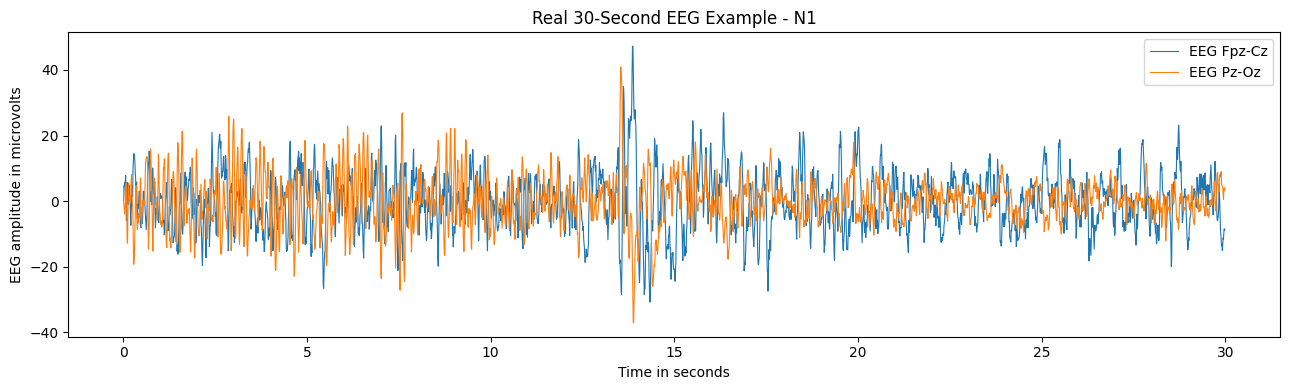

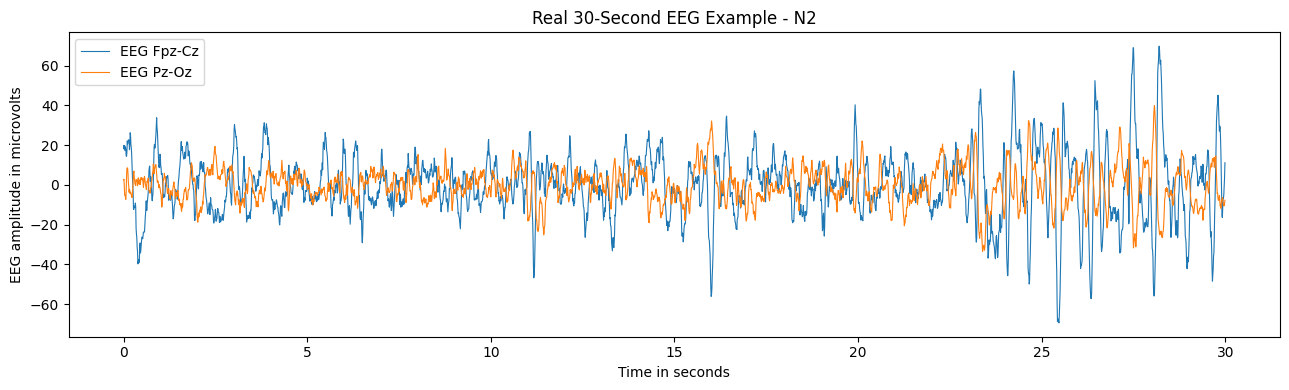

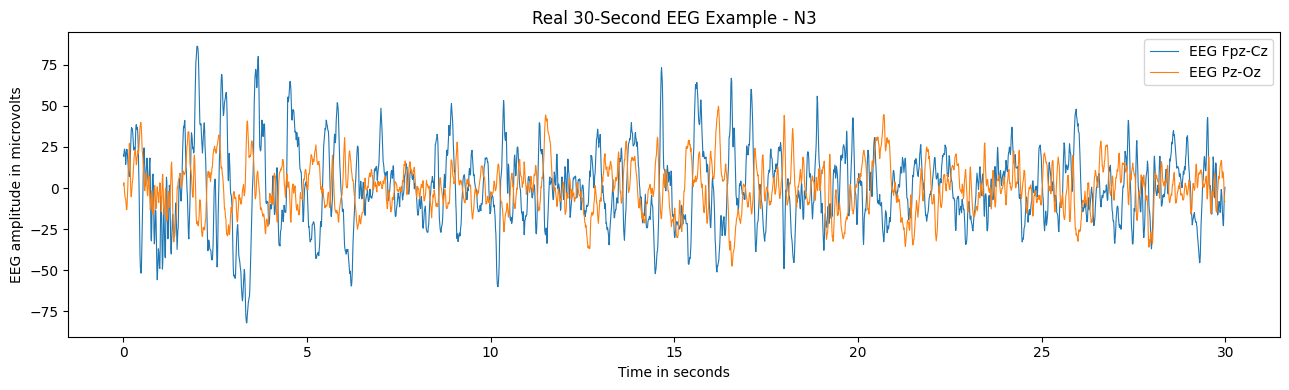

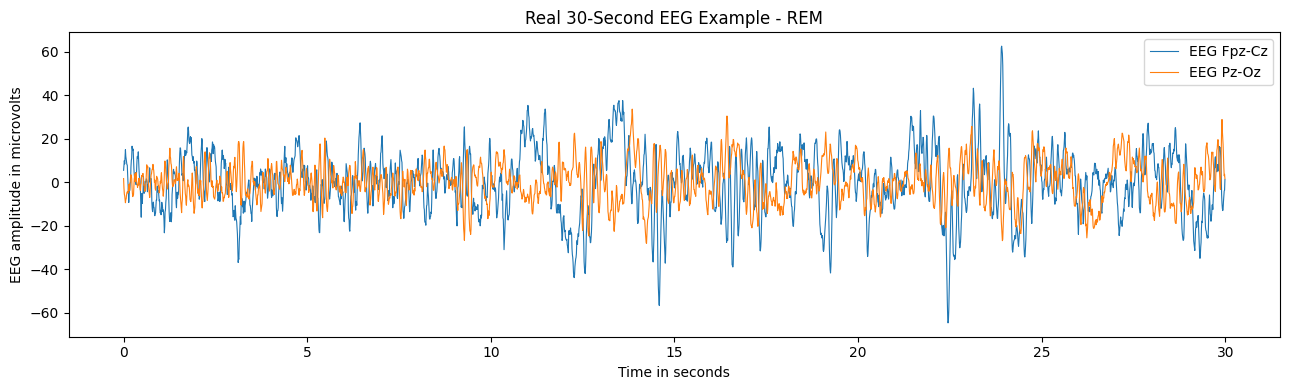

One saved recording array: (841, 3000, 2)
Meaning: samples × time values × EEG channels
One sample shape: (3000, 2)


In [ ]:
# SHOW A REAL EXAMPLE FROM EACH SLEEP STAGE

examples = {}

for _, row in processed_df.iterrows():
    saved = processed_data[
        row["data_file"]
    ]

    X = saved["X"]
    y = saved["y"]
    sampling_rate = int(
        saved[
            "sampling_rate"
        ]
    )

    for label_id, label_name in ID_TO_LABEL.items():
        positions = np.where(
            y == label_id
        )[0]

        if (
            label_name not in examples
            and len(positions) > 0
        ):
            examples[label_name] = (
                X[positions[0]],
                sampling_rate,
            )

    if len(examples) == len(
        CLASS_NAMES
    ):
        break


for label_name in CLASS_NAMES:
    if label_name not in examples:
        print(
            f"No saved example found for {label_name}"
        )
        continue

    sample, sampling_rate = (
        examples[label_name]
    )

    time_axis = (
        np.arange(
            sample.shape[0]
        )
        / sampling_rate
    )

    plt.figure(figsize=(13, 4))

    for channel_number, channel_name in enumerate(
        EEG_CHANNELS
    ):
        plt.plot(
            time_axis,
            (
                sample[
                    :,
                    channel_number,
                ]
                * 1e6
            ),
            linewidth=0.8,
            label=channel_name,
        )

    plt.title(
        f"Real 30-Second EEG Example - {label_name}"
    )
    plt.xlabel("Time in seconds")
    plt.ylabel(
        "EEG amplitude in microvolts"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR
        / f"example_{label_name}.png",
        dpi=150,
    )
    plt.show()


first_saved_file = (
    processed_df.iloc[0][
        "data_file"
    ]
)

saved = processed_data[
    first_saved_file
]

first_saved_X = saved["X"]
first_saved_y = saved["y"]


print(
    "One saved recording array:",
    first_saved_X.shape,
)

print(
    "Meaning: samples × time values × EEG channels"
)

print(
    "One sample shape:",
    first_saved_X[0].shape,
)


# Stage 7 - Model 1: Random Forest

## Why Random Forest?

Random Forest is used as the classical baseline model.

It is suitable because:

- it works well with calculated numerical features
- it can learn nonlinear relationships
- it does not normally require feature scaling
---

## Features calculated from each EEG channel

| Feature | Meaning |
|---|---|
| Mean | Average EEG value |
| Standard deviation | Amount of variation in the EEG values |
| Line length | How quickly the EEG waveform changes |
| Relative delta power | Signal power between 0.5 and 4 Hz |
| Relative theta power | Signal power between 4 and 8 Hz |
| Relative alpha power | Signal power between 8 and 13 Hz |
| Relative sigma power | Signal power between 12 and 16 Hz |
| Relative beta power | Signal power between 13 and 30 Hz |

---

The frequency powers are calculated relative to the total power between 0.5 and 30 Hz.

There are eight features for each EEG channel.

With two EEG channels, every 30-second sample produces:

`8 features × 2 channels = 16 features`

---


In [11]:
# CREATE RANDOM FOREST FEATURES


# Define the EEG frequency ranges.
FREQUENCY_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "sigma": (12, 16),
    "beta": (13, 30),
}


# Calculate features from a group of EEG samples.
def create_features(
    X,
    sampling_rate,
):
    # Store the calculated feature values.
    feature_values = {}


    # Process each EEG channel separately.
    for channel_number in range(
        X.shape[2]
    ):

        # Get all samples from the current channel.
        signal = X[
            :,
            :,
            channel_number,
        ]


        # Create a simple name for the channel.
        channel_name = (
            f"ch{channel_number + 1}"
        )


        # Calculate the mean EEG value.
        feature_values[
            f"mean_{channel_name}"
        ] = signal.mean(
            axis=1
        )


        # Calculate the standard deviation.
        feature_values[
            f"std_{channel_name}"
        ] = signal.std(
            axis=1
        )


        # Calculate the average change between nearby EEG values.
        feature_values[
            f"line_length_{channel_name}"
        ] = np.mean(
            np.abs(
                np.diff(
                    signal,
                    axis=1,
                )
            ),
            axis=1,
        )


        # Calculate the frequency power of the EEG signal.
        frequencies, power = welch(
            signal,
            fs=sampling_rate,
            nperseg=min(
                signal.shape[1],
                sampling_rate * 4,
            ),
            axis=1,
        )


        # Select the frequency range from 0.5 to 30 Hz.
        total_mask = (
            (frequencies >= 0.5)
            & (frequencies <= 30)
        )


        # Calculate the total power in the selected range.
        total_power = (
            trapezoid(
                power[
                    :,
                    total_mask,
                ],
                frequencies[
                    total_mask
                ],
                axis=1,
            )
            + 1e-12
        )


        # Calculate the relative power of every frequency band.
        for band_name, (
            low_frequency,
            high_frequency,
        ) in FREQUENCY_BANDS.items():

            # Select the frequencies belonging to this band.
            band_mask = (
                (
                    frequencies
                    >= low_frequency
                )
                & (
                    frequencies
                    < high_frequency
                )
            )


            # Calculate the power inside this frequency band.
            band_power = trapezoid(
                power[
                    :,
                    band_mask,
                ],
                frequencies[
                    band_mask
                ],
                axis=1,
            )


            # Divide band power by total power.
            feature_values[
                f"{band_name}_{channel_name}"
            ] = (
                band_power
                / total_power
            )


    # Return all calculated features as a table.
    return pd.DataFrame(
        feature_values
    )


# Set the path for the saved feature table.
features_path = (
    RESULTS_DIR
    / f"eeg_features_{RUN_TAG}.csv"
)


# Start by assuming that features must be calculated.
load_existing_features = False


# Check whether a matching feature table already exists.
if (
    features_path.exists()
    and not FORCE_PROCESS_DATA
):

    # Load the existing feature table.
    existing_features_df = pd.read_csv(
        features_path
    )


    # Check that the saved table matches the current samples.
    if (
        len(existing_features_df)
        == len(selected_samples_df)
        and np.array_equal(
            existing_features_df[
                "sample_id"
            ].to_numpy(),
            selected_samples_df[
                "sample_id"
            ].to_numpy(),
        )
    ):

        # Reuse the matching feature table.
        features_df = (
            existing_features_df
        )

        load_existing_features = True

        print(
            "Loaded the existing feature table."
        )


# Calculate features when a matching table was not loaded.
if not load_existing_features:

    # Store feature tables from all recordings.
    feature_parts = []


    # Group the sample table by recording.
    grouped_samples = (
        selected_samples_df.groupby(
            "data_file",
            sort=False,
        )
    )


    # Process the samples from every recording.
    for data_file, group in grouped_samples:

        # Keep the samples in their original order.
        group = group.sort_values(
            "sample_id"
        )


        # Get the processed EEG data from memory.
        saved = processed_data[
            data_file
        ]


        # Get the positions of the required samples.
        indices = group[
            "local_index"
        ].to_numpy()


        # Select the required EEG samples.
        selected_X = (
            saved["X"][
                indices
            ]
        )


        # Get the sampling rate of the recording.
        sampling_rate = int(
            saved[
                "sampling_rate"
            ]
        )


        # Calculate the Random Forest features.
        part = create_features(
            selected_X,
            sampling_rate,
        )


        # Add the sample IDs to the feature table.
        part.insert(
            0,
            "sample_id",
            group[
                "sample_id"
            ].to_numpy(),
        )


        # Add the subject IDs.
        part[
            "subject_id"
        ] = group[
            "subject_id"
        ].to_numpy()


        # Add the dataset split.
        part[
            "split"
        ] = group[
            "split"
        ].to_numpy()


        # Add the numeric sleep-stage labels.
        part[
            "label_id"
        ] = group[
            "label_id"
        ].to_numpy()


        # Add the sleep-stage names.
        part[
            "label_name"
        ] = group[
            "label_name"
        ].to_numpy()


        # Store this recording's feature table.
        feature_parts.append(
            part
        )


    # Combine all recording feature tables.
    features_df = pd.concat(
        feature_parts,
        ignore_index=True,
    )


    # Sort the final table by sample ID.
    features_df = (
        features_df
        .sort_values(
            "sample_id"
        )
        .reset_index(
            drop=True
        )
    )


    # Save the final feature table.
    features_df.to_csv(
        features_path,
        index=False,
    )


# Display the first five feature rows.
display(
    features_df.head()
)


# Print the number of rows and columns.
print(
    "Feature table shape:",
    features_df.shape,
)


Loaded the existing feature table.


,sample_id,mean_ch1,std_ch1,line_length_ch1,delta_ch1,theta_ch1,alpha_ch1,sigma_ch1,beta_ch1,mean_ch2,...,line_length_ch2,delta_ch2,theta_ch2,alpha_ch2,sigma_ch2,beta_ch2,subject_id,split,label_id,label_name
0,0,-2.157075e-07,0.000021,0.000005,0.862432,0.081296,0.013611,0.008699,0.025746,5.540525e-09,...,0.000002,0.362274,0.137304,0.377720,0.027884,0.058301,SC400,train,0,Wake
1,1,2.546159e-07,0.000025,0.000006,0.876200,0.076189,0.008379,0.003567,0.018298,5.830021e-08,...,0.000002,0.620680,0.107354,0.135134,0.038374,0.078714,SC400,train,0,Wake
2,2,-1.929078e-07,0.000031,0.000005,0.891488,0.075886,0.006333,0.002591,0.010276,-7.623688e-08,...,0.000002,0.692371,0.120254,0.062150,0.029976,0.068661,SC400,train,0,Wake
3,3,-5.095056e-07,0.000026,0.000006,0.868263,0.076312,0.009787,0.006229,0.027097,-9.859510e-08,...,0.000002,0.649080,0.111256,0.086611,0.032366,0.098043,SC400,train,0,Wake
4,4,1.975378e-07,0.000027,0.000006,0.868327,0.080725,0.010715,0.005453,0.020521,1.205537e-07,...,0.000002,0.630602,0.085640,0.188369,0.027089,0.054769,SC400,train,0,Wake


Feature table shape: (195462, 21)


Loaded the existing Random Forest.
Random Forest validation Macro F1: 0.6607


,feature,importance
15,beta_ch2,0.130322
1,std_ch1,0.108339
11,delta_ch2,0.080305
7,beta_ch1,0.076222
10,line_length_ch2,0.075014
2,line_length_ch1,0.071020
6,sigma_ch1,0.065729
13,alpha_ch2,0.064013
9,std_ch2,0.063700
3,delta_ch1,0.052148


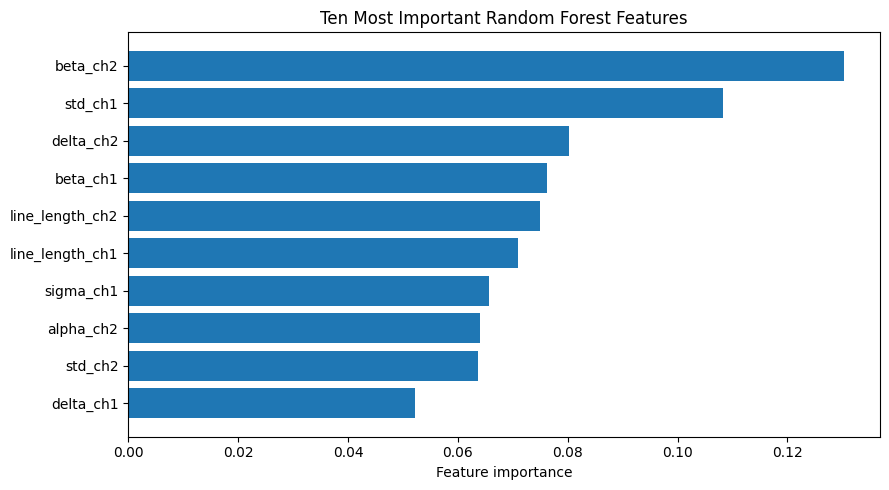

In [12]:
# TRAIN RANDOM FOREST


# Columns that contain sample information
# and are not used as model inputs.
metadata_columns = [
    "sample_id",
    "subject_id",
    "split",
    "label_id",
    "label_name",
]


# Keep only the calculated EEG feature columns.
feature_columns = [
    column
    for column in features_df.columns
    if column not in metadata_columns
]


# Get samples belonging to the training subjects.
train_features = features_df[
    features_df["split"] == "train"
]


# Get samples belonging to the validation subjects.
validation_features = features_df[
    features_df["split"] == "validation"
]


# Get samples belonging to the test subjects.
test_features = features_df[
    features_df["split"] == "test"
]


# Get the Random Forest input features
# for the training data.
X_train_rf = train_features[
    feature_columns
]


# Get the true training labels.
y_train_rf = train_features[
    "label_id"
]


# Get the Random Forest input features
# for the validation data.
X_validation_rf = validation_features[
    feature_columns
]


# Get the true validation labels.
y_validation_rf = validation_features[
    "label_id"
]


# Get the Random Forest input features
# for the unseen test data.
X_test_rf = test_features[
    feature_columns
]


# Get the true test labels.
y_test = test_features[
    "label_id"
].to_numpy()


# Set the path for the saved Random Forest model.
random_forest_path = (
    MODELS_DIR
    / f"random_forest_{RUN_TAG}.joblib"
)


# Start by assuming that a model must be trained.
load_existing_random_forest = False


# Check whether a saved model already exists.
if (
    random_forest_path.exists()
    and not FORCE_TRAIN_MODELS
):
    try:

        # Load the saved Random Forest model.
        rf_model = joblib.load(
            random_forest_path
        )


        # Check that the saved model expects
        # the same number of feature columns.
        if (
            rf_model.n_features_in_
            == len(feature_columns)
        ):
            load_existing_random_forest = True

            print(
                "Loaded the existing Random Forest."
            )

    except Exception:
        pass


# Train a new model when a matching model
# was not loaded.
if not load_existing_random_forest:

    # Create the Random Forest model.
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )


    # Train the model using the training data.
    rf_model.fit(
        X_train_rf,
        y_train_rf,
    )


    # Save the trained model.
    joblib.dump(
        rf_model,
        random_forest_path,
    )


# Predict the stages of the validation samples.
validation_prediction = rf_model.predict(
    X_validation_rf
)


# Calculate the validation Macro F1 score.
validation_macro_f1 = f1_score(
    y_validation_rf,
    validation_prediction,
    average="macro",
    zero_division=0,
)


# Display the validation Macro F1 score.
print(
    "Random Forest validation Macro F1:",
    round(
        validation_macro_f1,
        4,
    ),
)


# Create a table containing the importance
# of every EEG feature.
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": (
        rf_model.feature_importances_
    ),
})


# Keep the ten most important features.
importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False,
    )
    .head(10)
)


# Display the ten most important features.
display(
    importance_df
)


# Create the feature-importance graph.
plt.figure(figsize=(9, 5))

plt.barh(
    importance_df[
        "feature"
    ][::-1],
    importance_df[
        "importance"
    ][::-1],
)

plt.title(
    "Ten Most Important Random Forest Features"
)

plt.xlabel(
    "Feature importance"
)

plt.tight_layout()


# Save the feature-importance graph.
plt.savefig(
    FIGURES_DIR
    / "random_forest_feature_importance.png",
    dpi=150,
)


# Display the graph.
plt.show()


## Random Forest settings:

- **200 trees:** enough trees for a stable student baseline without making training unnecessarily slow.
- **Maximum depth 20:** limits extremely deep trees and helps reduce overfitting.
- **Balanced class weights:** gives more importance to smaller classes.

The feature-importance chart shows which calculated measurements the forest used most. 


# Stage 8 - Model 2: Compact 1D CNN

## 1D CNN:

EEG is a signal changing over time. A 1D convolution filter moves along the time axis and learns local waveform patterns

---

## Why this compact architecture?

`Input → 16 filters → pooling → 32 filters → pooling → global average → Dense 32 → five outputs`

---

| Choice | Reason |
|---|---|
| 16 then 32 filters | Gradually learns more patterns while keeping the network small |
| Kernel sizes 64 and 32 | Looks at medium and shorter EEG time windows |
| Max pooling by 4 | Reduces sequence length and training cost |
| Batch normalization | Stabilizes the values passed between layers |
| Dropout 0.25 | Reduces overfitting |
| Global average pooling | Avoids the very large Dense layer created by Flatten |
| Dense 32 | Combines the learned patterns |
| Softmax output 5 | Returns one probability for each sleep stage |

## Normalization:

Different subjects can have different EEG amplitudes. Each 30-second sample and each channel is changed to approximately:

- mean = 0
- standard deviation = 1

This helps the CNN focus more on waveform shape than absolute amplitude.


In [13]:
# LOAD AND NORMALIZE CNN DATA


# Load EEG samples for one dataset split.
def load_cnn_data(split_name):

    # Keep only rows belonging to the requested split.
    split_rows = (
        selected_samples_df[
            selected_samples_df[
                "split"
            ]
            == split_name
        ]
    )


    # Store EEG samples from all recordings.
    X_parts = []


    # Store the sleep-stage labels.
    y_parts = []


    # Store the sample IDs.
    sample_id_parts = []


    # Store the sampling rate.
    sampling_rate = None


    # Group the sample rows by recording.
    grouped_rows = (
        split_rows.groupby(
            "data_file",
            sort=False,
        )
    )


    # Process every recording in this split.
    for data_file, group in grouped_rows:

        # Keep samples in sample ID order.
        group = group.sort_values(
            "sample_id"
        )


        # Get the processed recording from memory.
        saved = processed_data[
            data_file
        ]


        # Get the positions of the required samples.
        indices = group[
            "local_index"
        ].to_numpy()


        # Add the selected EEG samples.
        X_parts.append(
            saved["X"][
                indices
            ].astype(
                np.float32
            )
        )


        # Add the matching sleep-stage labels.
        y_parts.append(
            saved["y"][
                indices
            ]
        )


        # Get the sampling rate of the recording.
        sampling_rate = int(
            saved[
                "sampling_rate"
            ]
        )


        # Add the sample IDs.
        sample_id_parts.append(
            group[
                "sample_id"
            ].to_numpy()
        )


    # Combine EEG samples from all recordings.
    X = np.concatenate(
        X_parts
    )


    # Combine all sleep-stage labels.
    y = np.concatenate(
        y_parts
    )


    # Combine all sample IDs.
    sample_ids = np.concatenate(
        sample_id_parts
    )


    # Find the correct order using sample IDs.
    order = np.argsort(
        sample_ids
    )


    # Put the EEG samples and labels
    # into the correct order.
    X = X[order]
    y = y[order]


    # Calculate the mean separately for
    # every sample and every EEG channel.
    sample_mean = X.mean(
        axis=1,
        keepdims=True,
    )


    # Calculate the standard deviation separately
    # for every sample and every EEG channel.
    sample_standard_deviation = (
        X.std(
            axis=1,
            keepdims=True,
        )
        + 1e-8
    )


    # Move each EEG channel around zero.
    X -= sample_mean


    # Place each EEG channel on a similar scale.
    X /= sample_standard_deviation


    # Return the EEG data, labels
    # and sampling rate.
    return (
        X.astype(
            np.float32
        ),
        y.astype(
            np.int64
        ),
        sampling_rate,
    )


# Load the CNN training data.
(
    X_train_cnn,
    y_train_cnn,
    CNN_SAMPLING_RATE,
) = load_cnn_data(
    "train"
)


# Load the CNN validation data.
(
    X_validation_cnn,
    y_validation_cnn,
    _,
) = load_cnn_data(
    "validation"
)


# Load the CNN test data.
(
    X_test_cnn,
    y_test_cnn,
    _,
) = load_cnn_data(
    "test"
)


# Check that the Random Forest and CNN
# test labels are in the same order.
assert np.array_equal(
    y_test,
    y_test_cnn,
)


# Print the shape of the CNN training data.
print(
    "CNN training shape:",
    X_train_cnn.shape,
)


# Print the shape of the CNN validation data.
print(
    "CNN validation shape:",
    X_validation_cnn.shape,
)


# Print the shape of the CNN test data.
print(
    "CNN test shape:",
    X_test_cnn.shape,
)

CNN training shape: (134042, 3000, 2)
CNN validation shape: (28058, 3000, 2)
CNN test shape: (33362, 3000, 2)


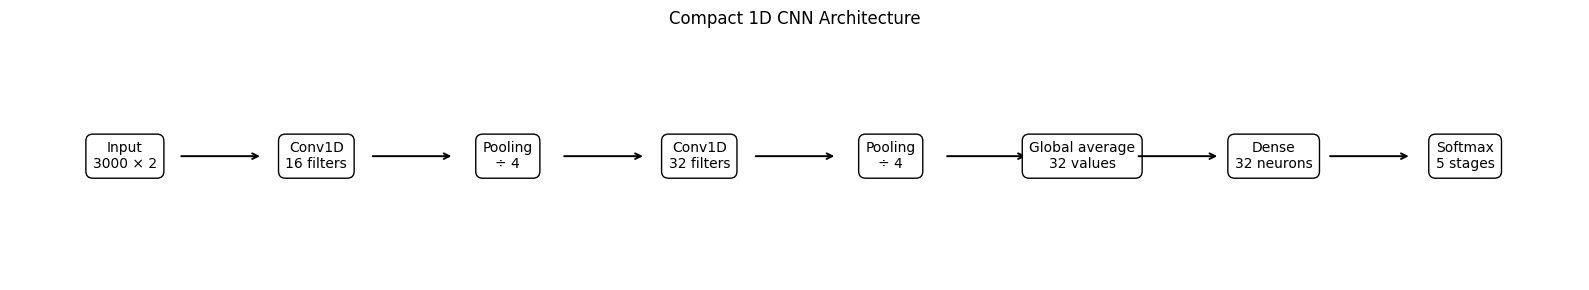

In [14]:
# CNN ARCHITECTURE

input_length = X_train_cnn.shape[1]

architecture_steps = [
    f"Input\n{input_length} × 2",
    "Conv1D\n16 filters",
    "Pooling\n÷ 4",
    "Conv1D\n32 filters",
    "Pooling\n÷ 4",
    "Global average\n32 values",
    "Dense\n32 neurons",
    "Softmax\n5 stages",
]

plt.figure(figsize=(16, 3))
plt.axis("off")

for position, step in enumerate(
    architecture_steps
):
    plt.text(
        position,
        0.5,
        step,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="black",
        ),
    )

    if position < len(
        architecture_steps
    ) - 1:
        plt.annotate(
            "",
            xy=(
                position + 0.72,
                0.5,
            ),
            xytext=(
                position + 0.28,
                0.5,
            ),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.4,
            ),
        )

plt.xlim(
    -0.6,
    len(architecture_steps)
    - 0.4,
)
plt.ylim(0, 1)
plt.title(
    "Compact 1D CNN Architecture"
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR
    / "compact_cnn_architecture.png",
    dpi=150,
)
plt.show()


In [15]:
# BUILD AND TRAIN THE COMPACT 1D CNN


# Create the CNN model.
def build_compact_cnn():
    model = Sequential([

        # Define the input shape:
        # number of time points and EEG channels.
        Input(
            shape=(
                X_train_cnn.shape[1],
                X_train_cnn.shape[2],
            )
        ),


        # Find basic EEG patterns over time.
        Conv1D(
            filters=16,
            kernel_size=64,
            padding="same",
            activation="relu",
        ),

        # Keep the values passed between layers stable.
        BatchNormalization(),

        # Reduce the number of time points.
        MaxPooling1D(
            pool_size=4
        ),

        # Randomly ignore some values during training
        # to help reduce overfitting.
        Dropout(0.25),


        # Learn more detailed EEG patterns.
        Conv1D(
            filters=32,
            kernel_size=32,
            padding="same",
            activation="relu",
        ),

        # Keep the values passed between layers stable.
        BatchNormalization(),

        # Reduce the number of time points again.
        MaxPooling1D(
            pool_size=4
        ),

        # Help reduce overfitting.
        Dropout(0.25),


        # Convert each learned pattern into one average value.
        GlobalAveragePooling1D(),


        # Combine the learned EEG patterns.
        Dense(
            32,
            activation="relu",
        ),

        # Help reduce overfitting.
        Dropout(0.25),


        # Return one probability for each sleep stage.
        Dense(
            len(CLASS_NAMES),
            activation="softmax",
        ),
    ])


    # Return the completed CNN model.
    return model


# Set the path for the saved CNN model.
cnn_path = (
    MODELS_DIR
    / f"compact_cnn_{RUN_TAG}.keras"
)


# Set the path for the saved training history.
history_path = (
    RESULTS_DIR
    / f"cnn_history_{RUN_TAG}.csv"
)


# Start by assuming that a CNN must be trained.
load_existing_cnn = False


# Check whether a saved CNN already exists.
if (
    cnn_path.exists()
    and not FORCE_TRAIN_MODELS
):
    try:

        # Load the saved CNN model.
        cnn_model = (
            tf.keras.models.load_model(
                cnn_path
            )
        )


        # Create the expected input shape.
        expected_shape = (
            None,
            X_train_cnn.shape[1],
            X_train_cnn.shape[2],
        )


        # Check that the saved model has
        # the correct input shape.
        if (
            cnn_model.input_shape
            == expected_shape
        ):
            load_existing_cnn = True

            print(
                "Loaded the existing CNN."
            )


    # Continue without stopping if the model
    # cannot be loaded.
    except Exception:
        pass


# Build and train a new CNN when
# a matching saved model was not loaded.
if not load_existing_cnn:

    # Create the CNN model.
    cnn_model = build_compact_cnn()


    # Set how the CNN learns and
    # how training performance is measured.
    cnn_model.compile(
        optimizer="adam",
        loss=(
            "sparse_categorical_crossentropy"
        ),
        metrics=["accuracy"],
    )


    # Find the sleep-stage classes
    # present in the training data.
    training_classes = np.unique(
        y_train_cnn
    )


    # Calculate weights for imbalanced classes.
    calculated_weights = (
        compute_class_weight(
            class_weight="balanced",
            classes=training_classes,
            y=y_train_cnn,
        )
    )


    # Convert the calculated weights
    # into the format required by the CNN.
    class_weights = {
        int(class_id): float(
            weight
        )
        for class_id, weight
        in zip(
            training_classes,
            calculated_weights,
        )
    }


    # Train the CNN using the training data
    # and check it using the validation data.
    history = cnn_model.fit(
        X_train_cnn,
        y_train_cnn,
        validation_data=(
            X_validation_cnn,
            y_validation_cnn,
        ),
        epochs=25,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[

            # Stop early if validation loss
            # does not improve.
            EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
            )
        ],
    )


    # Save the accuracy and loss values
    # recorded during training.
    pd.DataFrame(
        history.history
    ).to_csv(
        history_path,
        index=False,
    )


    # Save the trained CNN model.
    cnn_model.save(
        cnn_path
    )


# Display the CNN layers and parameters.
cnn_model.summary()

Epoch 1/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 186s 87ms/step - accuracy: 0.7044 - loss: 0.7498 - val_accuracy: 0.7182 - val_loss: 0.7135
Epoch 2/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 179s 85ms/step - accuracy: 0.7386 - loss: 0.6567 - val_accuracy: 0.6798 - val_loss: 0.7878
Epoch 3/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 179s 85ms/step - accuracy: 0.7446 - loss: 0.6320 - val_accuracy: 0.6701 - val_loss: 0.7877
Epoch 4/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 157s 75ms/step - accuracy: 0.7474 - loss: 0.6157 - val_accuracy: 0.7181 - val_loss: 0.7102
Epoch 5/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 159s 76ms/step - accuracy: 0.7496 - loss: 0.6062 - val_accuracy: 0.7138 - val_loss: 0.7053
Epoch 6/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 158s 75ms/step - accuracy: 0.7530 - loss: 0.5999 - val_accuracy: 0.7050 - val_loss: 0.7498
Epoch 7/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 155s 74ms/step - accuracy: 0.7549 - loss: 0.5921 - val_accuracy: 0.7228 - val_loss: 0.7055
Epoch 8/25
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 158s 75ms/step - accuracy: 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3000, 16)       │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3000, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 750, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 750, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 750, 32)        │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 750, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,489 (232.38 KB)

 Trainable params: 19,797 (77.33 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 39,596 (154.68 KB)

## CNN training settings:

- **Adam optimizer:** a common optimizer used to train neural networks.
- **Sparse categorical cross-entropy:** suitable because the sleep-stage labels are integers from 0 to 4.
- **Batch size 64:** balances memory use and training speed.
- **Maximum 25 epochs:** limits the training time when all usable samples are included.
- **Early stopping patience 4:** stops training if validation loss does not improve for four consecutive epochs.
- **Class weights:** gives more importance to sleep stages that have fewer training samples.
- **Validation subjects:** are different people from the training subjects.

The validation data is used to observe model performance during training. The unseen test subjects are not used for training decisions.


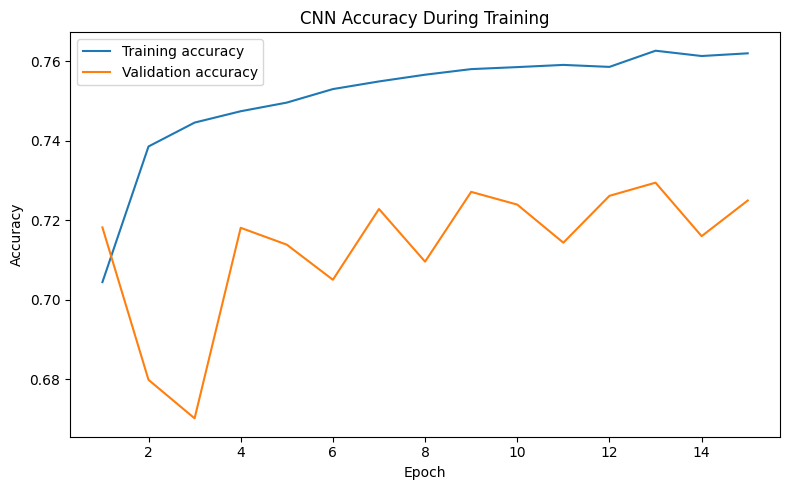

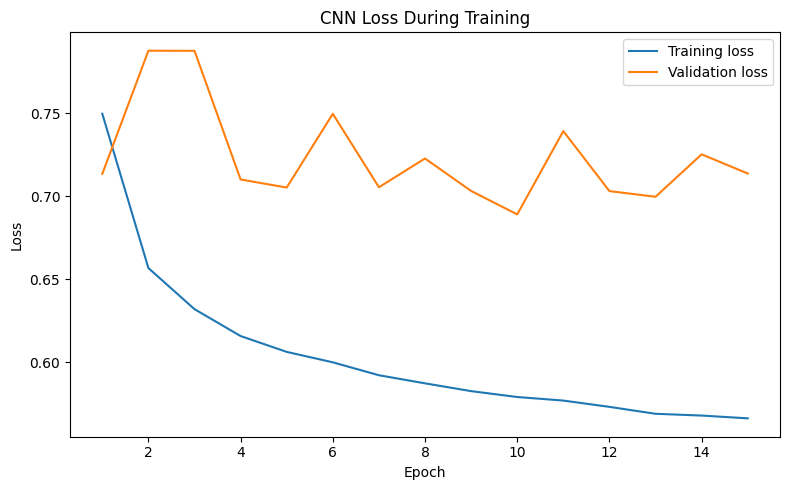

,accuracy,loss,val_accuracy,val_loss
0,0.704406,0.749785,0.718191,0.713545
1,0.738567,0.656747,0.679806,0.787796
2,0.744580,0.631960,0.670112,0.787733
3,0.747437,0.615749,0.718084,0.710150
4,0.749616,0.606194,0.713843,0.705291
5,0.753018,0.599900,0.705004,0.749751
6,0.754942,0.592111,0.722824,0.705460
7,0.756636,0.587229,0.709566,0.722813
8,0.758046,0.582532,0.727137,0.703242
9,0.758553,0.578984,0.723929,0.689103


In [16]:
# CNN TRAINING FIGURES


if history_path.exists():
    history_df = pd.read_csv(
        history_path
    )


    # Plot training and validation accuracy.
    plt.figure(figsize=(8, 5))

    plt.plot(
        range(
            1,
            len(history_df) + 1,
        ),
        history_df["accuracy"],
        label="Training accuracy",
    )

    plt.plot(
        range(
            1,
            len(history_df) + 1,
        ),
        history_df["val_accuracy"],
        label="Validation accuracy",
    )

    plt.title(
        "CNN Accuracy During Training"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / "cnn_training_accuracy.png",
        dpi=150,
    )

    plt.show()


    # Plot training and validation loss.
    plt.figure(figsize=(8, 5))

    plt.plot(
        range(
            1,
            len(history_df) + 1,
        ),
        history_df["loss"],
        label="Training loss",
    )

    plt.plot(
        range(
            1,
            len(history_df) + 1,
        ),
        history_df["val_loss"],
        label="Validation loss",
    )

    plt.title(
        "CNN Loss During Training"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / "cnn_training_loss.png",
        dpi=150,
    )

    plt.show()


    # Display the training history table.
    display(
        history_df
    )

else:
    print(
        "No CNN history file is available."
    )

# Stage 9 - Final evaluation on unseen subjects

The test subjects were not used for:

- Random Forest training,
- CNN training,
- validation decisions.
---

## Metrics

| Metric | Why it is reported |
|---|---|
| Accuracy | Overall percentage of correct predictions |
| Balanced accuracy | Gives equal importance to each class |
| Macro F1 | Main project metric; averages class F1 scores equally |
| Per-class precision/recall/F1 | Shows which stage is difficult |
| Confusion matrix | Shows the exact stage confusions |
| Per-subject Macro F1 | Shows whether performance changes between people |



,model,accuracy,balanced_accuracy,macro_f1
0,Compact 1D CNN,0.754002,0.757021,0.704189
1,Random Forest,0.769139,0.669627,0.674089


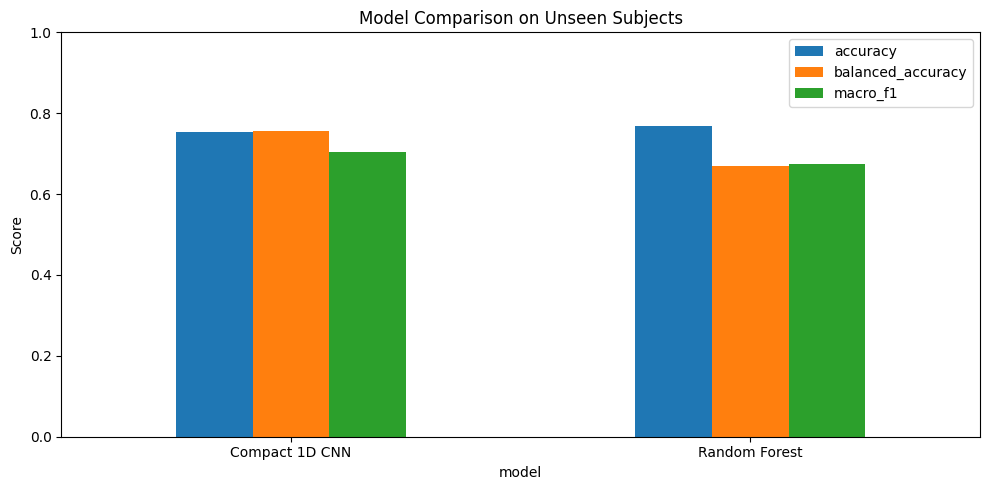

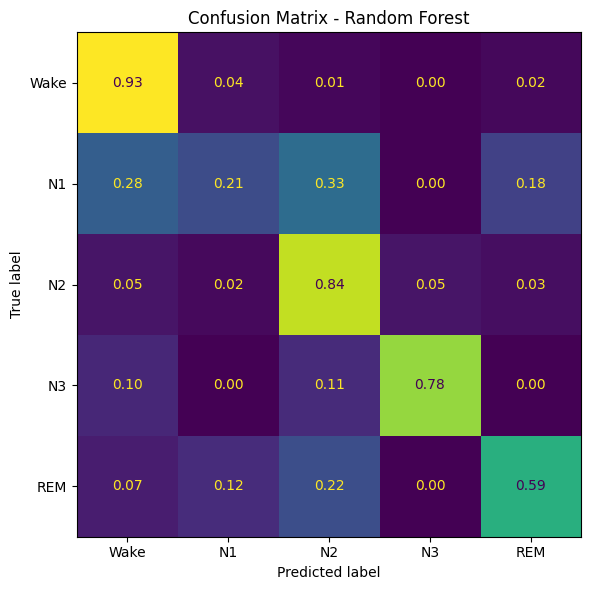

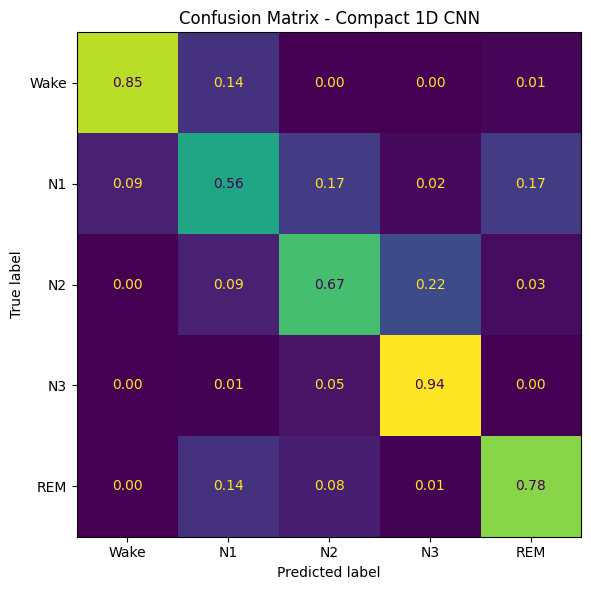

,model,sleep_stage,precision,recall,f1_score
0,Random Forest,Wake,0.836961,0.926055,0.879257
1,Random Forest,N1,0.376025,0.214494,0.273167
2,Random Forest,N2,0.787636,0.840804,0.813352
3,Random Forest,N3,0.773858,0.780817,0.777322
4,Random Forest,REM,0.675020,0.585965,0.627348
5,Compact 1D CNN,Wake,0.969268,0.845388,0.903100
6,Compact 1D CNN,N1,0.375271,0.556108,0.448134
7,Compact 1D CNN,N2,0.874124,0.665777,0.755856
8,Compact 1D CNN,N3,0.494687,0.941926,0.648690
9,Compact 1D CNN,REM,0.754721,0.775906,0.765167


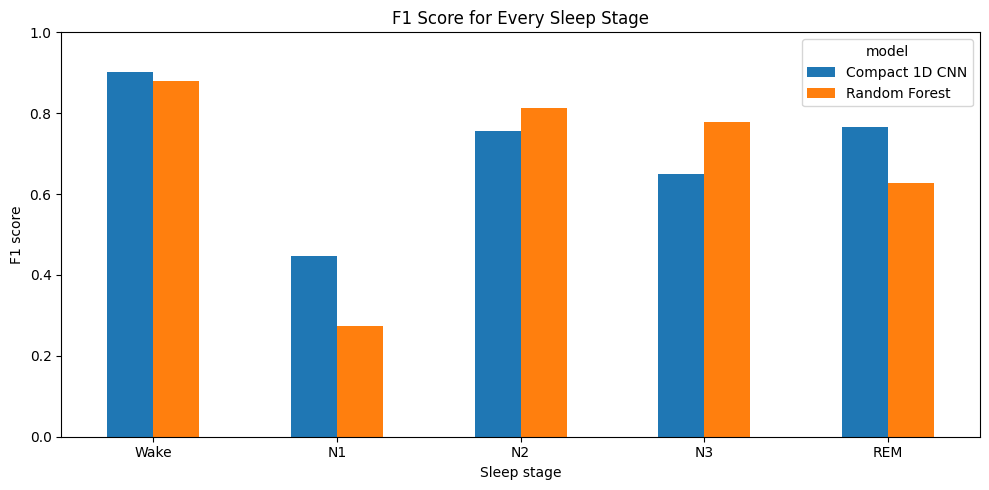

In [17]:
# COMPARE BOTH MODELS

rf_prediction = rf_model.predict(
    X_test_rf
)

cnn_probability = cnn_model.predict(
    X_test_cnn,
    verbose=0,
)

cnn_prediction = np.argmax(
    cnn_probability,
    axis=1,
)


def calculate_scores(
    model_name,
    prediction,
):
    return {
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            prediction,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_test,
                prediction,
            )
        ),
        "macro_f1": f1_score(
            y_test,
            prediction,
            average="macro",
            zero_division=0,
        ),
    }


comparison_df = pd.DataFrame([
    calculate_scores(
        "Random Forest",
        rf_prediction,
    ),
    calculate_scores(
        "Compact 1D CNN",
        cnn_prediction,
    ),
])

comparison_df = (
    comparison_df
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

comparison_df.to_csv(
    RESULTS_DIR
    / "model_comparison.csv",
    index=False,
)

display(
    comparison_df
)


comparison_plot = (
    comparison_df
    .set_index("model")[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ]
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5),
    rot=0,
)

plt.title(
    "Model Comparison on Unseen Subjects"
)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR
    / "model_comparison.png",
    dpi=150,
)
plt.show()


per_class_rows = []

for model_name, prediction in [
    (
        "Random Forest",
        rf_prediction,
    ),
    (
        "Compact 1D CNN",
        cnn_prediction,
    ),
]:
    report = classification_report(
        y_test,
        prediction,
        labels=range(
            len(CLASS_NAMES)
        ),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    for class_name in CLASS_NAMES:
        per_class_rows.append({
            "model": model_name,
            "sleep_stage": class_name,
            "precision": report[
                class_name
            ]["precision"],
            "recall": report[
                class_name
            ]["recall"],
            "f1_score": report[
                class_name
            ]["f1-score"],
        })


    normalized_matrix = (
        confusion_matrix(
            y_test,
            prediction,
            labels=range(
                len(CLASS_NAMES)
            ),
            normalize="true",
        )
    )

    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    ConfusionMatrixDisplay(
        normalized_matrix,
        display_labels=CLASS_NAMES,
    ).plot(
        ax=axis,
        values_format=".2f",
        colorbar=False,
    )

    axis.set_title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()

    safe_model_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_",
        )
    )

    plt.savefig(
        FIGURES_DIR
        / (
            "confusion_matrix_"
            + safe_model_name
            + ".png"
        ),
        dpi=150,
    )

    plt.show()


per_class_df = pd.DataFrame(
    per_class_rows
)

per_class_df.to_csv(
    RESULTS_DIR
    / "per_class_results.csv",
    index=False,
)

display(
    per_class_df
)


per_class_plot = (
    per_class_df
    .pivot(
        index="sleep_stage",
        columns="model",
        values="f1_score",
    )
    .reindex(
        CLASS_NAMES
    )
)

per_class_plot.plot(
    kind="bar",
    figsize=(10, 5),
    rot=0,
)

plt.title(
    "F1 Score for Every Sleep Stage"
)
plt.xlabel("Sleep stage")
plt.ylabel("F1 score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR
    / "per_class_f1.png",
    dpi=150,
)
plt.show()
